# Zoonosim Paper Notebook

Uses paper-1-version branch of zoonosim

We start by importing zoonosim and some other libraries we may need

In [1]:
import zoonosim as zn
import numpy as np
import seaborn as sns
import pandas as pd
import optuna as op
import matplotlib.pyplot as plt
from scipy import stats
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
from matplotlib.legend_handler import HandlerTuple
import sklearn
import json
import plotly

Zoonosim 0.0.2 (2026-03-03) — © 2025 by McGill University


Next we set up the options and project name

In [2]:
project_name = "all_prov_calibration"
zn.options.set(verbose=0) # How much output to print to the console (0 = none, 1 = some, 2 = all)
zn.options.set(numba_parallel='safe') # Whether to use parallel processing for numba-compiled functions. Options are 'safe', 'force', or 'off'.
zn.options.set(numba_cache=False) # Whether to cache numba-compiled functions to disk. Options are True or False.

Reloading Zoonosim so changes take effect...
Reload complete. Note: for some options to take effect, you may also need to delete Zoonosim's __pycache__ folder.
Reloading Zoonosim so changes take effect...
Reload complete. Note: for some options to take effect, you may also need to delete Zoonosim's __pycache__ folder.


Now we define our baseline parameters

In [3]:

baseline_pars = dict(
    # Peliminary parameters
    rand_seed = 21, # Random seed for the simulation. This is used to ensure that the results are reproducible.
    pop_scale = 1.0, # Scale factor for the population size. This is a vestigial parameter that is no longer used, but is kept for compatibility with older code.
    rescale = False, # Whether to rescale the population size to match the pop_size parameter. This is a vestigial parameter that is no longer used, but is kept for compatibility with older code.
    record_all_events = False, # Whether to record all events in the simulation. We set it to False during calibration to save memory.
    verbose = zn.options.get('verbose'), # How much output to print to the console (0 = none, 1 = some, 2 = all)

    # Simulation parameters

    agent_types = ['human', 'ppe', 'flock', 'barn', 'water'],
    n_farms = 50,
    pop_size = None, # This gets filled in when the population is generated
    pop_size_by_type = {}, # This gets filled in when the population is generated
    pop_pars = dict( # Parameters used for generating the population
        avg_barns_per_farm = 4.0, # Average number of barns per farm. Used to define the number of barns in the population. The actual number of barns per farm is drawn from a Poisson distribution with this mean.
        avg_humans_per_barn = 1.0, # We define the number of humans per barn rather than per farm to ensure larger farms have more humans. The actual number of humans per barn is drawn from a Poisson distribution with this mean.
        avg_water_per_farm = 0.75, # Average number of water sources per farm. The actual number of water sources per farm is drawn from a Poisson distribution with this mean. This value should be less than 1.0 to ensure that some farms share water sources.
        number_of_transients = 3, # Number of transient agents in the population. These are agents that move between farms and can spread disease between them.
        visits_per_day = 3, # Number of farms each transient visits in a day
    ),

    initial_conditions = dict( # dictates how many of each agent type are initially infected at the start of the simulation
        human = 0,
        ppe = 0,
        flock = 0,
        barn = 0,
        water = 0
    ),
    start_day = '2022-01-01', # The earliest day that we have data to calibrate the model to. This is used to set the start day of the simulation.
    end_day = '2025-12-31', # The latest day that we have data to calibrate the model to. This is used to set the end day of the simulation.
    n_days = None, # The number of days to run the simulation. If None, it will be set to the number of days between start_day and end_day.
    n_beds_hosp = None, # The number of hospital beds available in the population. If None, there is no restriction.
    no_hosp_factor = 1.0, # Change in mortality rate if hospital beds are not available. This is a multiplicative factor applied to the baseline mortality rate.
    beta = dict( # Beta values for each agent type.
        human = 0.0,
        ppe = 0.0,
        flock = 0.0,
        barn = 0.0,
        water = 0.0,
    ),
    n_imports = dict(
        human=None,  # Number of imported human cases per day; None = disabled
        flock=None,  # Number of imported flock cases per day; None = disabled
        ppe = None,   # Number of imported PPE contaminations per day; None = disabled
        barn=dict(import_pattern='seasonal', max_import_rate=0.2, peak_day=300),  # Number of imported barn contaminations per day; None = disabled
        water=dict(import_pattern='seasonal', max_import_rate=0.2, peak_day=300),  # Number of imported water contaminations per day; None = disabled
    ),
    transmission_pars = dict(
        human = dict(
                # beta_dist = dict(dist='neg_binomial', par1=1.0, par2=0.45, step=0.01), # Distribution to draw individual level transmissibility
                beta_dist = None,
                viral_loads = dict(minimum_load=3, peak_load=6),
                viral_levels = dict(min_scl=0.25, max_scl=1.0), # Specifies the range within which viral load should be scaled so it can contribute to relative transmissibility
                gamma_pars = dict(shape=2.0, scale=0.35) # Parameters for the gamma distribution used to determine the moment when an agents viral load exceeds the minimum detectable load.
        ),
        ppe = dict(
            # beta_dist = dict(dist='neg_binomial', par1=1.0, par2=0.45, step=0.01)
            beta_dist = None
        ),
        flock = dict(
            # beta_dist = dict(dist='neg_binomial', par1=1.0, par2=0.45, step=0.01)
            beta_dist = None
        ),
        barn = dict(
           # beta_dist = dict(dist='neg_binomial', par1=1.0, par2=0.45, step=0.01)
           beta_dist = None
        ),
        water = dict(
           # beta_dist = dict(dist='neg_binomial', par1=1.0, par2=0.45, step=0.01)
           beta_dist = None
        )
    ),
    immunity_pars = dict(
        human = dict(
        use_waning = True,
        nab_init = dict(dist='normal', par1=0, par2=2),  # Parameters for the distribution of the initial level of log2(nab) following natural infection, taken from fig1b of https://doi.org/10.1101/2021.03.09.21252641
        nab_decay = dict(form='nab_growth_decay', growth_time=21, decay_rate1=np.log(2) / 50, decay_time1=150, decay_rate2=np.log(2) / 250, decay_time2=365), # NOTE: I have no idea where this comes from
        nab_kin = None, # Constructed during sim initialization using the nab_decay parameters
        nab_boost = 1.5, # Multiplicative factor applied to a person's nab levels if they get reinfected.
        nab_eff = dict(alpha_inf=1.08, alpha_inf_diff=1.812, beta_inf=0.967, alpha_symp_inf=-0.739, beta_symp_inf=0.038, alpha_sev_symp=-0.014, beta_sev_symp=0.079), # Parameters to map nabs to efficacy
        rel_imm_symp = dict(asymp=0.85, mild=1, severe=1.5), # Relative immunity from natural infection varies by symptoms.
        immunity = None, # Matrix of immunity and cross-immunity factors, set by init_immunity() in immunity.py
        trans_redux = 0.59 # Reduction in transmission for breakthrough infection
        ),
        ppe = dict(use_waning = False),
        flock = dict(use_waning = False),
        barn = dict(use_waning = False),   
        water = dict(use_waning = False)
    ),
    dur = dict(
        human = dict(        # Duration: disease progression
            exp2inf = dict(dist='lognormal_int', par1=4.0, par2=2.0), # Duration from exposed to infectious
            inf2sym = dict(dist='lognormal_int', par1=4.0, par2=2.0), # Duration from infectious to symptomatic
            sym2sev = dict(dist='lognormal_int', par1=2.0, par2=1.0), # Duration from symptomatic to severe symptoms

            # Duration: Recovery
            asym2rec = dict(dist='lognormal_int', par1=8.0,  par2=2.0), # Duration for asymptomatic people to recover
            mild2rec = dict(dist='lognormal_int', par1=8.0,  par2=3.0), # Duration for people with mild symptoms to recover
            sev2rec = dict(dist='lognormal_int', par1=5.0, par2=3.0), # Duration for people with severe symptoms to recover
            sev2die = dict(dist='lognormal_int', par1=5.0, par2=3.0), # Duration from critical symptoms to death, 18.8 days total

            # Duration: quarantine
            quar = 7,
            # Duration: diagnosis
            diag = 14
        ),
        ppe = dict(        
            contamination = dict(dist='lognormal_int', par1=5.0, par2=3.0), # Duration of contamination.
            quar = 7, # Duration of quarantine after suspected exposure. NOTE: This should generally be the same as the human quarantine duration.
        ),
        flock = dict(
            # Duration: disease progression
            exp2inf = dict(dist='lognormal_int', par1=2.0, par2=1.0), # Duration from exposed to infectious. 
            inf2out = dict(dist='lognormal_int', par1=5.0, par2=2.0), # Duration from infectious to recovery/removal.
            susp2res = dict(dist='lognormal_int', par1=1.0, par2=0.25), # Duration from suspicion to a definitive test result. 

            # Duration: Quarantine
            quar = 14
        ),
        barn = dict(
            contamination = dict(dist='lognormal_int', par1=5, par2=3), # Duration of contamination. 
            composting = dict(dist='lognormal_int', par1=7.0, par2=1.5), # Duration of composting. 
            cleaning = dict(dist='lognormal_int', par1=7.0, par2=1.5), # Duration of cleaning process. 
        ),
        water = dict(
             contamination = dict(dist='lognormal_int', par1=5.0, par2=3.0), # Duration of contamination. 
        )
    ),
    poultry_pars = dict(
        breeds = np.array(['poultry'], dtype=zn.default_str),
        breed_freqs = np.array([1.0]),
        mortality_suspicion_threshold = [0.002], # I.E a deviation from the expected mortality rate of 0.01*expected_value will trigger suspicion
        symptomatic_suspicion_threshold = [0.002], # I.E a deviation from the expected symptomatic rate of 0.01*expected_value will trigger suspicion
        consumption_suspicion_threshold = [0.002], # I.E a deviation from the expected rate of water consumption of 0.01*expected_value will trigger suspicion
        cycle_dur = [dict(dist = 'normal_pos', par1 = 100, par2 = 25)],
        flock_size = [dict(dist = 'normal_pos', par1 = 25000, par2 = 10000)]
    ),
    prognoses = dict(
        human = dict(
            age_cutoffs   = np.array([0]),     # Age cutoffs (lower limits)
            sus_ORs       = np.array([1.00]),    # Odds ratios for relative susceptibility 
            trans_ORs     = np.array([0.00]),    # Odds ratios for relative transmissibility
            comorbidities = np.array([1.00]),    # Comorbidities by age -- set to 1 by default since already included in disease progression rates
            symp_probs    = np.array([0.96]),    # relative probability of developing symptoms 
            severe_probs  = np.array([0.38]),     # relative probability of developing severe symptoms
            death_probs   = np.array([0.02]),    # relative probability of dying
        ),
        ppe = dict(
            sus_ORs = np.array([1.00]),
            trans_ORs = np.array([1.00]),
        ),
        flock = dict(
            breeds = np.array(['poultry'], dtype=zn.default_str),
            sus_ORs = np.array([1.00]),
            trans_ORs = np.array([1.00]),
            baseline_symptomatic_rate = np.array([0.001]),
            infected_symptomatic_rate = np.array([1.00]),
            baseline_mortality_rate = np.array([0.001]),
            baseline_water_rate = np.array([1.00]),
            water_rate_increase = np.array([0.20])
        ),
        barn = dict(
            sus_ORs = np.array([1.00]),
            trans_ORs = np.array([1.00]),
        ),
        water = dict(
            sus_ORs = np.array([0.00]),
            trans_ORs = np.array([1.00]),
        )
    ),

    # Smartwatch parameters
    enable_smartwatches = False,
    # smartwatch_pars = dict(
    #     who                       = 'all', # Must be one of 'all', 'permanent', 'transient'; controls who receives smartwatches
    #     mean_fpr                  =   0.08, # mean false positive rate
    #     use_variable_fpr          = True, # Whether to use a variable false positive rate
    #     day_i                     = np.arange(-21, 22, 1), #
    #     loc                       = 3.25, # Day of max probability of alert, relative to the day of symptom onset.
    #     alpha                     = 1, # Scales the probability of receiving an alert
    #     usage_rate                = 1, # Out of people who have smartwatches, the amount who use download the alerting app and stick with it.
    #     compliance_rate           =   0.05, # probability of quarantining if a smartwatch detects symptoms (only used if testobjs are not available)
    #     participation_rate        =   0.3,  # proportion of the population that has a smartwatch
    # ),

    bkg_ILI = 0.0, # proportion of the population that is infected with Influenza-like-illness at any given time
    Avian_to_ILI = False, # If True agents can be infected with both Avian Influenza and an ILI

    # Bells and whistles

    interventions = [], # The interventions present in this simulation; populated by the user
    surveillance = [], # The surveillance systems present in this simulation; populated by the user
    testing = [], # The testing systems present in this simulation; populated by the user. These can be populated externally, or internally by supplying a parameter dictionary. 
    analyzers = [], # Custom analysis functions; populated by the user
    timelimit = None, # Time limit for the simulation (seconds)
    stopping_func = None, # A function to call to stop the sim partway through
    vaccine_pars = {}, # Vaccines that are being used; populated during initialization
    vaccine_map = {}, # Reverse mapping from number to vaccine key

    # Pathogen specific parameters
    wild = dict(
        human = dict(
            rel_beta = 1.0,
            rel_symp_prob = 1.0,
            rel_severe_prob = 1.0,
            rel_death_prob = 1.0,
            rel_asymp_fact = 1.0

        ),
        ppe = dict(
            rel_beta = 1.0,
            rel_dur_contamination = 1.0
        ),
        flock = dict(
            rel_beta = 1.0,
            rel_symp_delta = 1.0,
            rel_death_delta = 1.0,
            rel_water_delta = 1.0
        ),
        barn = dict(
            rel_beta = 1.0,
            rel_dur_contamination = 1.0
        ),
        water = dict(
            rel_beta = 1.0,
            rel_dur_contamination = 1.0
        )
    ),

    variants = [], # Additional variants of the virus; populated by the user, see immunity.py
    variant_map = {0:'wild'}, # Reverse mapping from number to variant key
    variant_pars = dict(
        wild = dict(
            human = dict(
                rel_beta = 1.0,
                rel_symp_prob = 1.0,
                rel_severe_prob = 1.0,
                rel_death_prob = 1.0,
                rel_asymp_fact = 1.0

            ),
            ppe = dict(
                rel_beta = 1.0,
                rel_dur_contamination = 1.0
            ),
            flock = dict(
                rel_beta = 1.0,
                rel_symp_delta = 1.0,
                rel_death_delta = 1.0,
                rel_water_delta = 1.0
            ),
            barn = dict(
                rel_beta = 1.0,
                rel_dur_contamination = 1.0
            ),
            water = dict(
                rel_beta = 1.0,
                rel_dur_contamination = 1.0
            )
        ),
    ),
)

zn.reset_layer_pars(baseline_pars)

## Calibration Step

Now we need to prepare the data that we will be calibrating against.

In [4]:
original_data = pd.read_csv("../zoonosim/data/CFIA_original_dataset.csv")
clean_data = original_data.rename(columns={'Infected Premises (IP) location Question': 'Infected premises', 
                                              'Premises type Question': 'Premises type',
                                              'WOAH premises classification Question': 'Premises classification',
                                              'Primary control zone (PCZ) Question - Map': 'PCZ',
                                              'Status of order declaring PCZ': 'PCZ status'})
clean_data['Infected premises'] = clean_data['Infected premises'].str.extract(r"^([A-Z]{2}-IP\d+)")
clean_data = clean_data[clean_data['Premises type'] == 'commercial']
clean_data = clean_data[clean_data['Premises classification'] == 'poultry']

manipulated_data = clean_data[['Date detected', 'Province']]
manipulated_data = manipulated_data.rename(columns={'Date detected': 'date', 'Province': 'province'})
manipulated_data['date'] = pd.to_datetime(manipulated_data['date'], format='%B %d, %Y')

daily_timeseries = (
    manipulated_data
    .sort_values("date")
    .groupby(["date", "province"])
    .size()
    .unstack(fill_value=0)              # daily counts per province   
    .asfreq("D", fill_value=0)          # ensure every date appears
    #.reset_index('date', drop=False)
)

full_date_range = pd.date_range(start=daily_timeseries.index.min().replace(day = 1, month=1), end=daily_timeseries.index.max(), freq='D')

daily_timeseries = daily_timeseries.reindex(full_date_range, fill_value=0).reset_index().rename(columns={'index': 'date'})

daily_timeseries['date'] = pd.to_datetime(daily_timeseries['date'])
monthly_timeseries = daily_timeseries.groupby(pd.Grouper(key='date', freq='ME')).sum().reset_index()


no_poultry_farms = {
    'BC': 314,
    'AB': 245,
    'SK': 68,
    'MB': 126,
    'ON': 1322,
    'QC': 623,
    'NS': 100,
    'PEI': 8,
    'NFLD': 6,
    'CA': 2377
}

province_codes = {
    'British Columbia' : 'BC',
    'Alberta' : 'AB',
    'Saskatchewan' : 'SK',
    'Manitoba' : 'MB',
    'Ontario' : 'ON',
    'Quebec' : 'QC',
    'Nova Scotia' : 'NS',
}

no_simulated_farms = baseline_pars['n_farms']


for province in province_codes.keys():
    new_col_name = f'{province}_adjusted_{no_simulated_farms}'
    monthly_timeseries[new_col_name] = (monthly_timeseries[province]/no_poultry_farms[province_codes[province]])*no_simulated_farms

provincial_data = {}
scale_adjustments = {}
for province in province_codes.keys():
    calibration_column = str(province) + "_adjusted_" + str(no_simulated_farms)
    calibration_data = monthly_timeseries[['date', calibration_column]].copy()
    calibration_data = calibration_data.rename(columns={calibration_column:"monthly_new_poultry_flock_infectious"})
    provincial_data[province] = calibration_data
    scale_adjustments[province] = no_poultry_farms[province_codes[province]]/no_simulated_farms

In [6]:
provincial_data['Quebec']

province,date,monthly_new_poultry_flock_infectious
0,2022-01-31,0.000000
1,2022-02-28,0.000000
2,2022-03-31,0.000000
3,2022-04-30,0.321027
4,2022-05-31,0.000000
5,2022-06-30,0.080257
6,2022-07-31,0.240770
7,2022-08-31,0.080257
8,2022-09-30,0.000000
9,2022-10-31,0.481541


Now we create the simulation object

In [5]:
calibration_sims=[]
for province in province_codes.keys():
    temp_label = province + '_' + project_name # Note: label must start with {province}_ so that the pars sampler can choose the right subdict.
    temp_sim = zn.Sim(datafile=provincial_data[province], label = temp_label, pars=baseline_pars)
    calibration_sims.append(temp_sim)

If we want we can save these pars now. If you don't need or want to save your parameters the following cell can be skipped.

In [6]:
for sim in calibration_sims:
    sim.export_pars(f"../saved_pars/{sim.label}.json")
# calibration_sim.export_pars(f"../saved_pars/{project_name}.json")

And we can load them back in here. Note that the process of converting the pars into JSON format can mess up stratified parameters (e.g. human and flock prognosis) so there is some extra code here to get the reloaded pars into the correct format. As always I've done my best to make everything automatic but it may break especially if you are trying something new. 

If you have run all the cells above this one than all the params are already defined and there is no need to run the following cell.

If you want to include calibration data in your simulation you may need to rerun that cell.

In [ ]:

# pars_name = project_name # Replace the RHS with the name of the pars you want to load
# pars_filename = f"../saved_pars/{pars_name}.json"


def import_pars(pars_filename):
    with open(pars_filename, 'r') as file:
        project_pars = json.load(file)

    for key, value in project_pars['prognoses']['human'].items():
        project_pars['prognoses']['human'][key] = np.array(value)
    for key, value in project_pars['prognoses']['flock'].items():
        if key == 'breed':
            project_pars['prognoses']['flock'][key] = np.array(value, dtype=zn.default_str)
        else:
            project_pars['prognoses']['flock'][key] = np.array(value)
    for key, value in project_pars['poultry_pars'].items():
        if key == 'breeds':
            project_pars['poultry_pars'][key] = np.array(value, dtype=zn.default_str)
    return project_pars

calibration_pars = {}
for province in province_codes.keys():
    pars_name = province.replace(" ", "_") + "_" + project_name
    pars_filename = f"../saved_pars/{pars_name}.json"
    pars = import_pars(pars_filename)
    calibration_pars[province] = pars

In [ ]:
# calibration_sim = zn.Sim(datafile = calibration_data, label = project_name, pars = project_pars)

calibration_sims = []
for province in province_codes.keys():
    sim_name = province + "_" + project_name
    sim_pars = calibration_pars[province]
    sim_data = provincial_data[province]
    sim = zn.Sim(datafile = sim_data, label=sim_name, pars=sim_pars)
    calibration_sims.append(sim)

And the last step before calibration is to specify what parameters can be adjusted and in what range. For any given parameter that we want to calibrate against we need to provide a list of three values, the first value in the list is the 'expected', or 'starting' value, this is the value that Optuna will start it's calibration from. the second and third value are the minimum and maximum respectively, they define the range of values that optuna will explore during calibration. This can all get a little tricky when parameters are in nested dicts or are stratified, I've done my best to make it all automatic but there are still issues now and then. If things aren't working it probably means you will have to make adjustments in analysis.py and/or utils/pars_ops.py. When using MultiCalibrate two dicts must be provided, one global dict for pars that are shared among all sims and one local dict for pars that are specific to each sim.

In [11]:
global_calibration_pars = dict(
    beta = dict(
        human = [0.01, 0.00, 0.25],
        # ppe = [0.05, 0.00, 0.25],
        # flock = [0.10, 0.00, 0.25],
        # barn = [0.15, 0.00, 0.25],
        # water = [0.20, 0.00, 0.25]
    ),
    beta_layer = dict(
        human_ppe = [0.02, 0.00, 1.00],
        #human_human = [0.02, 0.00, 1.00], # No human to human interaction so this is superfluous.
        human_flock = [0.02, 0.00, 1.00],
        human_barn = [0.02, 0.00, 1.00],
        human_water = [0.02, 0.00, 1.00],
        ppe_ppe = [0.02, 0.00, 1.00],
        ppe_flock = [0.02, 0.00, 1.00],
        ppe_barn = [0.02, 0.00, 1.00],
        ppe_water = [0.02, 0.00, 1.00],
        flock_barn = [0.02, 0.00, 1.00],
        flock_water = [0.02, 0.00, 1.00],
        barn_water = [0.02, 0.00, 1.00],
        transient = [0.02, 0.00, 1.00]
    )
)

local_pars = dict(
                n_imports = dict(
                    barn = dict(
                        max_import_rate = [0.2, 0.0, 1.0],
                        peak_day = [275, 1, 365]
                    ),
                    water = dict(
                    max_import_rate = [0.2, 0.0, 1.0],
                    )
                ),
)

local_calibration_pars = {}
for province in province_codes.keys():
    local_calibration_pars[province] = local_pars


Now we can create and execute the calibration object

In [8]:
fit_args = dict(
    clip=True, # Sets zeros to 10e-9, so we can use mean_poisson_deviance without crashing.
    normalize=False,
    use_frac=False,
    use_squared=False,
    as_scalar='none',
    skestimator='mean_poisson_deviance'    
)

multicalibrator = zn.MultiCalibration_Slow(calibration_sims, 
                                           global_calibration_pars, 
                                           local_calibration_pars, 
                                           custom_fn=zn.custom_assignment,
                                           fit_args=fit_args,
                                           n_reps = 7, 
                                           n_trials=5,
                                           name=project_name,
                                           die=True,
                                           keep_db=False,
                                           parallel_mode = 'trials' # 'Trials' or 'Reps'
                                           )


# calibrator = zn.Calibration(calibration_sim, calibration_pars, custom_fn = zn.custom_assignment, name = project_name, n_reps = 20, total_trials=100, die=False, keep_db=True, fit_args=fit_args)



In [9]:
if __name__ == "__main__": # This is needed because Windows is weird.
    multicalibrator.calibrate()

# if __name__ == "__main__": # This is needed because Windows is weird. 
#     calibrator.calibrate()

Removed existing calibration ../studies/all_prov_calibration.db


[I 2026-10-08 15:19:40,403] A new study created in Journal with name: all_prov_calibration


TypeError: MultiCalibration_Slow.run_multisim() got an unexpected keyword argument 'calib_pars'

The database created by the calibration gets saved in the studies folder. If we want we can load it from there, for example to avoid redoing the calibration process

In [5]:
study_name = project_name # Replace the RHS with the name of the study you want to load
db_name = f'../studies/{study_name}.db'
study = op.load_study(study_name= study_name, storage=op.storages.JournalStorage(op.storages.journal.JournalFileBackend(db_name, op.storages.journal.JournalFileSymlinkLock(db_name))))

In [6]:
op.visualization.plot_edf([study]).show()


In [7]:
op.visualization.plot_optimization_history(study).show()

In [8]:
op.visualization.plot_param_importances(study).show()

And now we are able to see the results of the calibration

In [9]:
all_trials = study.trials_dataframe()
all_trials['value'].describe()

count      80.000000
mean      182.110801
std       375.711926
min        26.044216
25%        45.295908
50%        67.398601
75%       104.826087
max      2156.273674
Name: value, dtype: float64

Now that we have scores for all our trials we need to decide which trial parameters we should include in our ensemble.

In [12]:
mean_poisson_deviance = all_trials['value']
chi = mean_poisson_deviance*len(calibration_data) # because mpd = 2*(log-likelihood_perfect - log-likelihood_zoonosim) = -2 ln (likelihood_zoonosim/likelihood_perfect)
calibration_pars = global_calibration_pars | local_calibration_pars

def count_leaf_entries(d):
    return sum(count_leaf_entries(v) if isinstance(v, dict) else 1 for v in d.values())

df = count_leaf_entries(calibration_pars)

chi95 = stats.chi2.ppf(0.95, df)

cutoff = np.min(chi) + chi95

top_inds = np.where(chi<cutoff)[0]

top_trials = all_trials.iloc[top_inds]
len(top_trials)

2

In [16]:
top_trials

,number,value,datetime_start,datetime_complete,duration,params_Alberta.n_imports.barn.max_import_rate,params_Alberta.n_imports.barn.peak_day,params_Alberta.n_imports.water.max_import_rate,params_British Columbia.n_imports.barn.max_import_rate,params_British Columbia.n_imports.barn.peak_day,...,params_beta_layer.human_flock,params_beta_layer.human_ppe,params_beta_layer.human_water,params_beta_layer.ppe_barn,params_beta_layer.ppe_flock,params_beta_layer.ppe_ppe,params_beta_layer.ppe_water,params_beta_layer.transient,system_attrs_tpe:relative_params:0,state
30,30,26.513817,2026-10-08 15:40:45.034672,2026-10-08 15:59:02.498584,0 days 00:18:17.463912,0.879406,71.243897,0.976619,0.298838,334.715723,...,0.540882,0.314014,0.527877,0.473470,0.295725,0.421591,0.490836,0.450942,"{""Alberta.n_imports.barn.max_import_rate"": 0.8...",COMPLETE
75,75,26.044216,2026-10-08 16:35:40.938424,2026-10-08 16:52:57.019044,0 days 00:17:16.080620,0.523865,315.382669,0.703967,0.090568,360.839117,...,0.184484,0.859191,0.077023,0.838378,0.045762,0.958852,0.655466,0.559898,"{""Alberta.n_imports.barn.max_import_rate"": 0.5...",COMPLETE


Now we have found our top performing trials we need to convert them into the correct format for parameters. This can be done manually but it's slow and tedious so we will endeavour to automate it here. Note that the automation function is designed for the specific parameters being calibrated here, if you change the calibration parameters this may not work.

In [14]:
top_pars = []


for index, row in top_trials.iterrows():
    trial_pars = dict()
    trial_pars['global'] = dict(
        beta = dict(
            human = row['params_beta.human'],
            ppe = row['params_beta.human'], # because beta is equal for all agent types
            flock = row['params_beta.human'],
            barn = row['params_beta.human'],
            water = row['params_beta.human']
        ),

        beta_layer = dict(
        human_ppe = row['params_beta_layer.human_ppe'],
        # human_human = row['params_beta_layer.human_human'],
        human_flock = row['params_beta_layer.human_flock'],
        human_barn = row['params_beta_layer.human_barn'],
        human_water = row['params_beta_layer.human_water'],
        ppe_ppe = row['params_beta_layer.ppe_ppe'],
        ppe_flock = row['params_beta_layer.ppe_flock'],
        ppe_barn = row['params_beta_layer.ppe_barn'],
        ppe_water = row['params_beta_layer.ppe_water'],
        flock_barn = row['params_beta_layer.flock_water'],
        flock_water = row['params_beta_layer.flock_water'],
        barn_water = row['params_beta_layer.barn_water'],
        transient = row['params_beta_layer.transient']
        )
    )

    for province in province_codes.keys():
        trial_pars[province] = dict(
            n_imports = dict(
                barn = dict(
                    max_import_rate = row[f'params_{province}.n_imports.barn.max_import_rate'],
                    peak_day = row[f'params_{province}.n_imports.barn.peak_day']
                ),
                water = dict(
                    max_import_rate = row[f'params_{province}.n_imports.water.max_import_rate'],
                    peak_day = row[f'params_{province}.n_imports.barn.peak_day'] # waters peak day is fixed to equal barns
                )
            )
        )

    top_pars.append(trial_pars)

## Baseline Multisim

Now that we have our calibrated parameters we can put them all in an msim object and run the baseline simulation.

In [15]:
good_pars = dict()
rand_seed = 17 #gotta start somewhere
for province in province_codes.keys():
    for index, pars in enumerate(top_pars):
        rand_seed += index + 1
        temp_pars = pars['global'] | pars[province]
        temp_pars['rand_seed'] = rand_seed
        good_pars[f'{province}_index'] = temp_pars


# for i in range(0,len(top_pars)):
#     temp_label = f'{project_name}_sim_{i}_baseline'
#     temp_sim = zn.Sim(datafile=calibration_data, label=temp_label, pars=baseline_pars)
#     temp_sim.update_pars(pars = top_pars[i], recursive = True)
#     baseline_sims.append(temp_sim)

# baseline_msim = zn.MultiSim(baseline_sims, n_runs = 1000, verbose = zn.options.get('verbose'))

Next we have to create a msim object with the pars we want to investigate. I'll do this by province.

In [16]:
focus = 'Ontario' # must be a Canadian province. No data for NB.
reps = 10
top_sims = []

for key in good_pars.keys():
    if key.split('_')[0] == focus:
        temp_pars = good_pars[key]
        for index in range(reps):
            temp_pars['rand_seed'] += index
            temp_label = f'{key}_{index}'
            temp_sim = zn.Sim(datafile = provincial_data[focus], label = temp_label, pars=baseline_pars)
            temp_sim.update_pars(temp_pars, recursive=True)
            top_sims.append(temp_sim)


top_msim = zn.MultiSim(top_sims, verbose=zn.options.get('verbose'), label=focus)

And now we can run the multisim.

In [17]:
if __name__ == "__main__": # This is needed because Windows is weird. 
    top_msim.run(keep_people = True, run_args = dict(auto_finalize = False), parallel=True)
    top_msim.finalize()
    top_msim.shrink()
    top_msim.save(f'../msims/{project_name}_{focus.replace(" ", "_")}_w_data.msim')

In [18]:
current_msim = zn.MultiSim.load(f'../msims/{project_name}_{focus.replace(" ", "_")}_w_data.msim')
current_msim.reduce(use_mean=True, bounds=1)


In [102]:
current_msim.result_keys()

['new_human_exposed',
 'new_human_reinfections',
 'new_human_infections',
 'new_human_infectious',
 'new_human_symptomatic',
 'new_human_severe',
 'new_human_recovered',
 'new_human_dead',
 'new_human_tested',
 'new_human_diagnosed',
 'new_human_known_dead',
 'new_human_quarantined',
 'new_human_doses',
 'new_human_vaccinated',
 'new_ppe_contaminated',
 'new_ppe_uncontaminated',
 'new_ppe_quarantined',
 'new_flock_exposed',
 'new_flock_infectious',
 'new_flock_suspected',
 'new_flock_quarantined',
 'new_poultry_flock_exposed',
 'new_poultry_flock_infectious',
 'new_poultry_flock_suspected',
 'new_poultry_flock_quarantined',
 'new_barn_contaminated',
 'new_barn_uncontaminated',
 'new_barn_composted',
 'new_barn_cleaned',
 'new_water_contaminated',
 'new_water_uncontaminated',
 'n_human_susceptible',
 'n_human_exposed',
 'n_human_infectious',
 'n_human_symptomatic',
 'n_human_severe',
 'n_human_recovered',
 'n_human_dead',
 'n_ppe_contaminated',
 'n_ppe_uncontaminated',
 'n_ppe_quarantin

In [19]:
basic_data = pd.DataFrame({ 'date': current_msim.base_sim.datevec,
                            'new infectious humans mean': current_msim.results['monthly_new_human_infectious'].values,
                            'new infectious humans high': current_msim.results['monthly_new_human_infectious'].high,
                            'new infectious humans low': np.clip(current_msim.results['monthly_new_human_infectious'].low, min=0.00),
                            'new infectious poultry mean': current_msim.results['monthly_new_poultry_flock_infectious'].values,
                            'new infectious poultry high': current_msim.results['monthly_new_poultry_flock_infectious'].high,
                            'new infectious poultry low': np.clip(current_msim.results['monthly_new_poultry_flock_infectious'].low, min=0.00)
                            })
basic_data['date'] = pd.to_datetime(basic_data['date'])
monthly_data=basic_data[basic_data['date'].dt.is_month_end]
monthly_data['new infectious poultry actual'] = provincial_data[focus]['monthly_new_poultry_flock_infectious'].values
#monthly_data['new infectious humans actual'] = calibration_data['monthly_new_human_infectious'].values
monthly_data

,date,new infectious humans mean,new infectious humans high,new infectious humans low,new infectious poultry mean,new infectious poultry high,new infectious poultry low,new infectious poultry actual
30,2022-01-31,0.0,0.000000,0.0,0.0,0.000000,0.000000,0.000000
58,2022-02-28,0.0,0.000000,0.0,0.0,0.000000,0.000000,0.000000
89,2022-03-31,0.0,0.000000,0.0,0.2,0.600000,0.000000,0.113464
119,2022-04-30,0.0,0.000000,0.0,0.9,2.120656,0.000000,0.491679
150,2022-05-31,0.9,3.285372,0.0,1.0,2.183216,0.000000,0.151286
180,2022-06-30,0.6,1.263325,0.0,1.1,2.235782,0.000000,0.000000
211,2022-07-31,0.0,0.000000,0.0,0.9,1.730662,0.069338,0.000000
242,2022-08-31,0.6,2.096663,0.0,0.9,1.944031,0.000000,0.000000
272,2022-09-30,0.0,0.000000,0.0,0.3,0.940312,0.000000,0.075643
303,2022-10-31,0.2,0.800000,0.0,0.4,1.063325,0.000000,0.037821


In [20]:
scaled_monthly_data = monthly_data.copy()
numeric_cols = scaled_monthly_data.select_dtypes(include='number').columns
scaled_monthly_data[numeric_cols] *= scale_adjustments[focus]
scaled_monthly_data

,date,new infectious humans mean,new infectious humans high,new infectious humans low,new infectious poultry mean,new infectious poultry high,new infectious poultry low,new infectious poultry actual
30,2022-01-31,0.000,0.000000,0.0,0.000,0.000000,0.000000,0.0
58,2022-02-28,0.000,0.000000,0.0,0.000,0.000000,0.000000,0.0
89,2022-03-31,0.000,0.000000,0.0,5.288,15.864000,0.000000,3.0
119,2022-04-30,0.000,0.000000,0.0,23.796,56.070133,0.000000,13.0
150,2022-05-31,23.796,86.865238,0.0,26.440,57.724230,0.000000,4.0
180,2022-06-30,15.864,33.402312,0.0,29.084,59.114067,0.000000,0.0
211,2022-07-31,0.000,0.000000,0.0,23.796,45.758713,1.833287,0.0
242,2022-08-31,15.864,55.435769,0.0,23.796,51.400170,0.000000,0.0
272,2022-09-30,0.000,0.000000,0.0,7.932,24.861860,0.000000,2.0
303,2022-10-31,5.288,21.152000,0.0,10.576,28.114312,0.000000,1.0


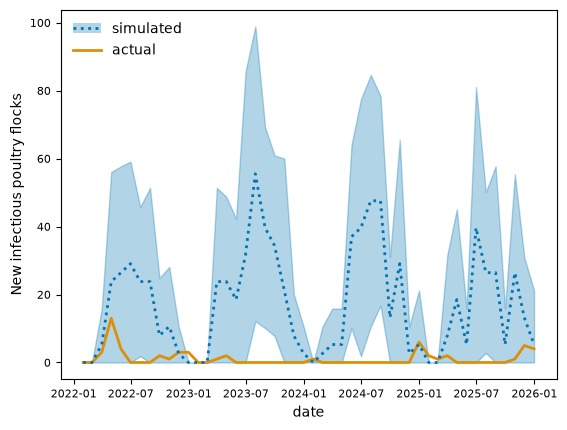

In [21]:
mean = Line2D([0], [0], color='#0173b2', linestyle='dotted', label='mean', linewidth = 2)
variance = mpatches.Patch(facecolor='#0173b2', alpha=0.3)
actual = Line2D([0], [0], color='#de8f05', label='actual', linewidth = 2)
legend_handles = [(mean, variance), actual]
poultry_fig, poultry_ax = plt.subplots()
sns.lineplot(x='date', y='new infectious poultry actual', data = scaled_monthly_data, color = '#de8f05', ax=poultry_ax, legend=True, linewidth=2)
sns.lineplot(x='date', y='new infectious poultry mean', data = scaled_monthly_data, color = '#0173b2', linestyle='dotted', ax=poultry_ax, legend=True, linewidth=2)
poultry_ax.fill_between(scaled_monthly_data['date'], scaled_monthly_data['new infectious poultry low'], scaled_monthly_data['new infectious poultry high'], color='#0173b2', alpha=0.3)
poultry_ax.tick_params(axis='both', which='major', labelsize=8)
poultry_ax.legend(
    handles=legend_handles,
    labels=['simulated', 'actual'],
    loc = 'upper left',
    frameon=False,
    handler_map={tuple: HandlerTuple(ndivide=None, pad=-2)}
)
poultry_ax.set_ylabel('New infectious poultry flocks')
plt.show()


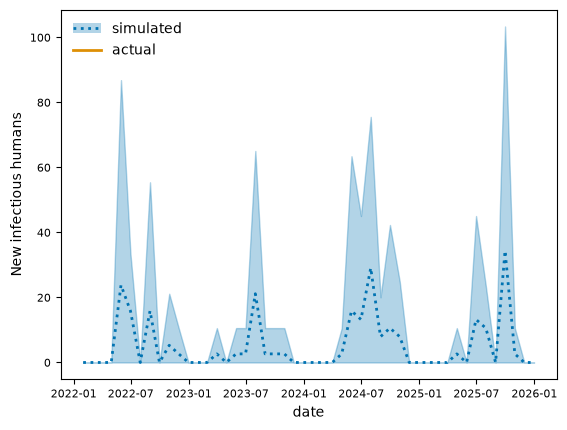

In [22]:
mean = Line2D([0], [0], color='#0173b2', linestyle='dotted', label='mean', linewidth = 2)
variance = mpatches.Patch(facecolor='#0173b2', alpha=0.3)
actual = Line2D([0], [0], color='#de8f05', label='actual', linewidth = 2)
legend_handles = [(mean, variance), actual]
human_fig, human_ax = plt.subplots()
#sns.lineplot(x='date', y='new infectious humans actual', data = monthly_data, color = '#de8f05', ax=human_ax, legend=True, linewidth=2)
sns.lineplot(x='date', y='new infectious humans mean', data = scaled_monthly_data, color = '#0173b2', linestyle='dotted', ax=human_ax, legend=True, linewidth=2)
human_ax.fill_between(scaled_monthly_data['date'], scaled_monthly_data['new infectious humans low'], scaled_monthly_data['new infectious humans high'], color='#0173b2', alpha=0.3)
human_ax.tick_params(axis='both', which='major', labelsize=8)
human_ax.legend(
    handles=legend_handles,
    labels=['simulated', 'actual'],
    loc = 'upper left',
    frameon=False,
    handler_map={tuple: HandlerTuple(ndivide=None, pad=-2)}
)
human_ax.set_ylabel('New infectious humans')
plt.show()

In [23]:
seasonality_data = pd.DataFrame({
    'date': current_msim.base_sim.datevec,
    'barns mean': current_msim.results['n_barn_contaminated'].values,
    'barns high': current_msim.results['n_barn_contaminated'].high,
    'barns low': np.clip(current_msim.results['n_barn_contaminated'].low, min=0.00),
    'water mean': current_msim.results['n_water_contaminated'].values,
    'water high': current_msim.results['n_water_contaminated'].high,
    'water low': np.clip(current_msim.results['n_water_contaminated'].low, min=0.00)
})

scaled_seasonality_data = seasonality_data.copy()
numeric_cols = scaled_seasonality_data.select_dtypes(include="number").columns
scaled_seasonality_data[numeric_cols] *= scale_adjustments[focus]

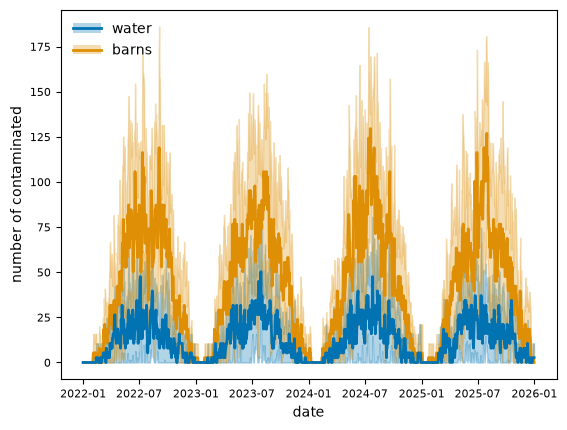

In [24]:
water_mean = Line2D([0], [0], color='#0173b2', label='mean', linewidth = 2)
water_variance = mpatches.Patch(facecolor='#0173b2', alpha=0.3)
barn_mean = Line2D([0], [0], color='#de8f05', label='mean', linewidth = 2)
barn_variance = mpatches.Patch(facecolor='#de8f05', alpha=0.3)
legend_handles = [(water_mean, water_variance), (barn_mean, barn_variance)]
seasonality_fig, seasonality_ax = plt.subplots()
sns.lineplot(x='date', y='barns mean', data = scaled_seasonality_data, color = '#de8f05', ax=seasonality_ax, legend=True, linewidth=2)
sns.lineplot(x='date', y='water mean', data = scaled_seasonality_data, color = '#0173b2', ax=seasonality_ax, legend=True, linewidth=2)
seasonality_ax.fill_between(scaled_seasonality_data['date'], scaled_seasonality_data['water low'], scaled_seasonality_data['water high'], color='#0173b2', alpha=0.3)
seasonality_ax.fill_between(scaled_seasonality_data['date'], scaled_seasonality_data['barns low'], scaled_seasonality_data['barns high'], color='#de8f05', alpha=0.3)
seasonality_ax.tick_params(axis='both', which='major', labelsize=8)
seasonality_ax.legend(
    handles=legend_handles,
    labels=['water', 'barns'],
    loc = 'upper left',
    frameon=False,
    handler_map={tuple: HandlerTuple(ndivide=None, pad=-2)}
)
seasonality_ax.set_ylabel('number of contaminated')
plt.show()

In [25]:
from collections import defaultdict

def merge_dicts(dict_list):
    # This automatically creates a list or a nested defaultdict when a key is missing
    merged = defaultdict(lambda: defaultdict(list) if 'nested' else list) 
    
    def recurse(target, source):
        for key, value in source.items():
            if isinstance(value, dict):
                # If the target doesn't have this sub-dict yet, initialize it
                if key not in target:
                    target[key] = defaultdict(list)
                # Dig deeper into the nested dictionary
                recurse(target[key], value)
            else:
                # If it's a number, append it to the list
                # Convert a standard dict to a defaultdict on the fly if needed
                if not isinstance(target, defaultdict) and isinstance(target, dict):
                    # This handles initializing empty lists in standard dicts
                    target.setdefault(key, []).append(value)
                else:
                    target[key].append(value)

    # Loop through all your input dictionaries
    for d in dict_list:
        recurse(merged, d)
        
    # Optional: Convert back to regular dicts for clean printing
    return json_to_dict(merged)

def json_to_dict(d):
    """Helper to convert defaultdicts back to standard dicts."""
    if isinstance(d, defaultdict) or isinstance(d, dict):
        return {k: json_to_dict(v) for k, v in d.items()}
    return d

In [ ]:
merged_top_pars = merge_dicts(top_pars)
top_pars_lists = json_to_dict(merged_top_pars)

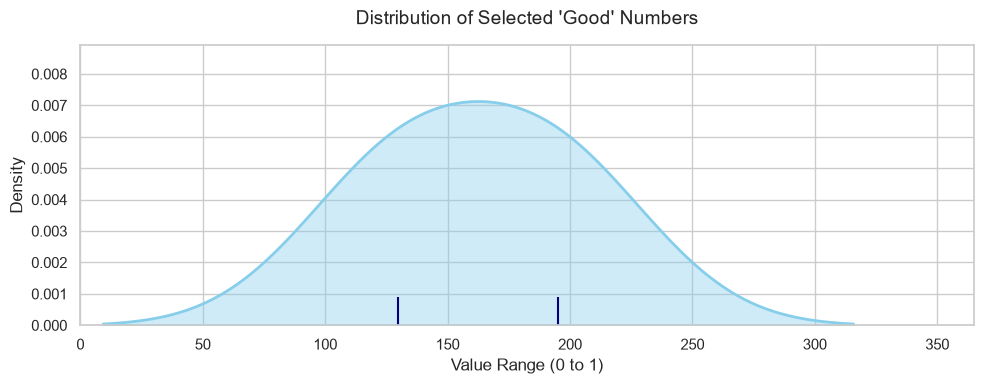

In [37]:
# 1. Get the 'good numbers' from top_pars_list. Remember the first key is either 'global' for pars that applied to all provinces or {province} for pars unique to a specific province.
good_numbers = top_pars_lists['Quebec']['n_imports']['barn']['peak_day']
range_min = 0 # Minimum value in the range typically 0.
range_max = 365 # Maximum value in range, typically 1.
# 2. Set up the plotting style
sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(10, 4))

# 3. Plot the distribution curve (KDE)
sns.kdeplot(x=good_numbers, ax=ax, fill=True, color="skyblue", alpha=0.4, linewidth=2)

# 4. Add the 1D Strip Plot / Rug Plot at the bottom (y=0)
# We use a rugplot here because it draws clean vertical ticks right on the axis line
sns.rugplot(x=good_numbers, ax=ax, color="navy", height=0.1, linewidth=1.5)

# 5. Fine-tune the chart limits and labels
ax.set_xlim(range_min, range_max)  # Keeps the strict 0 to 1 range of your uniform selection
ax.set_title("Distribution of Selected 'Good' Numbers", fontsize=14, pad=15)
ax.set_xlabel("Value Range (0 to 1)", fontsize=12)
ax.set_ylabel("Density", fontsize=12)

plt.tight_layout()
plt.show()